In [1]:
import torch
import torchvision
import torch.nn.functional as F
from torchvision.transforms import v2
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import torchvision.transforms.functional as F_t
import numpy as np
from torchvision.utils import make_grid
from tqdm import trange
from geometry_tools import lerp
from conditional_gmm import ConditionalGMM
from posterior_manifold import FisherLogPosteriorManifold
from utils import categorical_entropy

transform = v2.Compose([
    v2.Resize((64, 64), interpolation=v2.InterpolationMode.BILINEAR),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
])
dataset = torchvision.datasets.MNIST(root='datasets', transform=transform, download=True, train=False)
dataloader = DataLoader(dataset, batch_size=16, shuffle=False, num_workers=4)

def show_img(img, figsize=None, ax=None):
    if not ax:
        fig = plt.figure(figsize=figsize)
        ax = fig.add_subplot()
    img = img.detach()
    img = F_t.to_pil_image(img)
    ax.imshow(np.asarray(img), cmap='gray')
    ax.set(xticklabels=[], yticklabels=[], xticks=[], yticks=[])

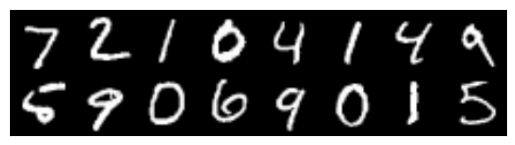

In [2]:
imgs, labels = next(dataloader.__iter__())
seven = imgs[0]
show_img(make_grid(imgs))

/net/st1/export/clusterhome/robertwiebe/ml_geometry_project/repos/torch_vae/model.py:288: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict(torch.load(fname

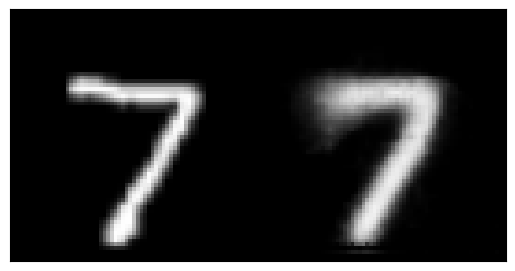

In [4]:
from pretrained_models import MNIST_VAE
vae = MNIST_VAE(n_latent=2)
with torch.no_grad():
    reconstructed = vae.decode(vae.encode(seven))
    show_img(make_grid(torch.stack((seven, reconstructed))))

In [5]:
colors = np.array(['blue', 'orange', 'green', 'red', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan'])
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', label=str(i), markerfacecolor=col) for i, col in enumerate(colors)]

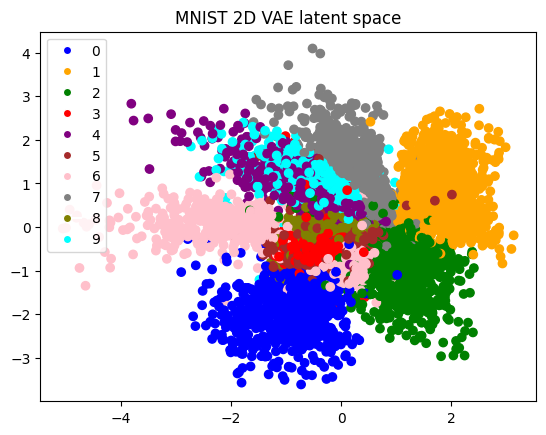

In [6]:
for images, class_labels in dataloader:
    with torch.no_grad():
        latent = vae.encode(images.cuda()).cpu()
    plt.scatter(*latent.T, c=colors[class_labels.numpy()])
plt.legend(handles=legend_elements)
plt.title('MNIST 2D VAE latent space')
plt.show()

In [7]:
gmm = ConditionalGMM(n_dim=2, n_classes=10)
with torch.no_grad():
    for images, class_labels in dataloader:
        gmm.update(vae.encode(images.cuda()), class_labels.cuda())
    gmm.fit()

In [51]:
def psd_mat_sqrt(mats: torch.Tensor):
    eigvals, eigvecs = torch.linalg.eigh(mats)
    return torch.einsum('kid, kd, kjd -> kij', eigvecs, torch.sqrt(eigvals), eigvecs)
def unit_circle(resolution: int = 32):
    t = torch.linspace(0, 2*torch.pi, resolution+1)
    return torch.stack((torch.cos(t), torch.sin(t)), dim=-1)
def plot_2d_gmm(means: torch.Tensor, covs: torch.Tensor, scale_fac=1.5, resolution: int=32, color='k', ax=None):
    means, covs = means.detach().cpu(), covs.detach().cpu()
    ellipsoids = scale_fac*torch.einsum('kid,rd->irk', psd_mat_sqrt(covs), unit_circle(resolution)) + means.T[:, None, :]
    if ax:
        ax.plot(*ellipsoids, c=color)
    else:
        plt.plot(*ellipsoids, c=color)

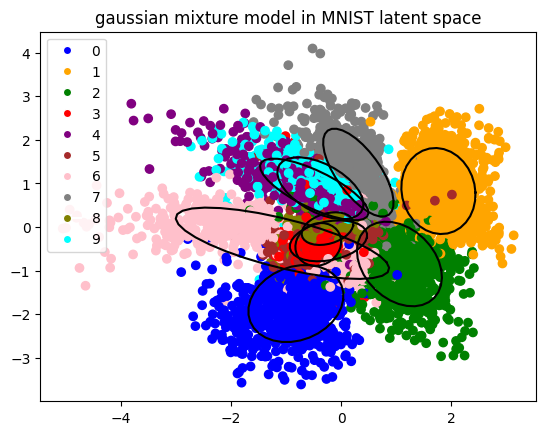

In [9]:
for images, class_labels in dataloader:
    with torch.no_grad():
        latent = vae.encode(images)
    plt.scatter(*latent.T, c=colors[class_labels.numpy()])
plt.legend(handles=legend_elements)
plt.title('gaussian mixture model in MNIST latent space')
plot_2d_gmm(gmm.means, gmm.covs)

In [10]:
M = FisherLogPosteriorManifold(gmm.log_posterior)

In [ ]:
xmin, xmax, ymin, ymax = -5.0, 3.0, -3.5, 3.5
X = torch.arange(xmin+0.5, xmax-0.5, 0.05)
Y = torch.arange(ymin+0.5, ymax-0.5, 0.05)
grid = torch.stack(torch.meshgrid(X, Y, indexing='xy'), dim=-1)

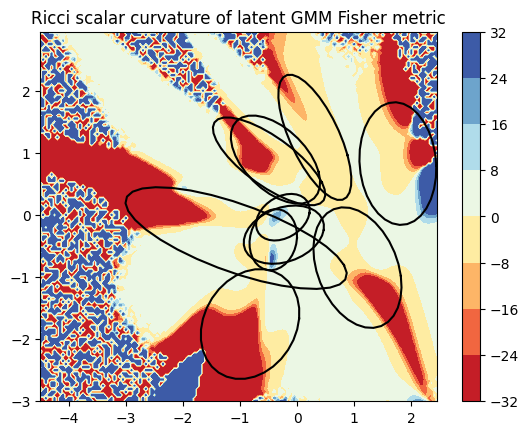

In [13]:
ric_grid = torch.clamp(M.ric(grid.cuda()).detach().cpu(), min=-30, max=30)
plt.contourf(X, Y, ric_grid, cmap='RdYlBu')
plt.colorbar()
plt.title('Ricci scalar curvature of latent GMM Fisher metric')
plot_2d_gmm(gmm.means, gmm.covs)
plt.show()

In [15]:
import torch.nn as nn
class LatentGenerativeClassifier(nn.Module):
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return gmm.log_posterior(vae.encode(x))
model = LatentGenerativeClassifier()

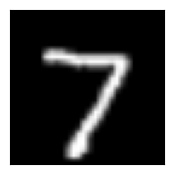

In [18]:
show_img(imgs[0], figsize=(2, 2))

In [20]:
model(seven.cuda())

tensor([-16.0609,  -4.5908,  -6.6887, -18.6946,  -7.4845, -16.3726, -19.5538,
         -0.0306, -17.8407,  -4.0068], device='cuda:0', grad_fn=<SubBackward0>)

## Adversarial attacks: FGSM and OSSA

### FSGM (normal)

In [42]:
def fsgm_attack(image: torch.Tensor, target: int, epsilon: float):
    og_device = image.device
    img_cuda = image.cuda().requires_grad_()
    logits: torch.Tensor = model(img_cuda)
    init_pred = logits.argmax().item()
    loss = F.nll_loss(logits, torch.as_tensor(target, device='cuda'))
    data_grad: torch.Tensor = torch.autograd.grad(loss, img_cuda)[0]
    sign_data_grad = data_grad.sign()
    perturbed_img = torch.clamp(img_cuda + epsilon*sign_data_grad, 0, 1)
    perturbed_pred = model(perturbed_img).argmax().item()
    return perturbed_img.to(og_device), init_pred, perturbed_pred

In [67]:
from matplotlib.gridspec import GridSpec
def show_fsgm_attack(image: torch.Tensor, target: int, epsilon: float):
    fig = plt.figure(figsize=(9, 5))
    gs = GridSpec(1, 2, width_ratios=[1, 2], figure=fig)
    axr = fig.add_subplot(gs[0, 1])
    gs_left = gs[0, 0].subgridspec(2, 1)
    axlu = fig.add_subplot(gs_left[0, 0])
    axll = fig.add_subplot(gs_left[1, 0])
    show_img(image, ax=axlu)
    perturbed, init_pred, final_pred = fsgm_attack(image, target, epsilon)
    show_img(perturbed, ax=axll)
    axlu.set_title(f'Original (classified: {init_pred})')
    axll.set_title(f'Perturbed (classified: {final_pred})')
    plot_2d_gmm(gmm.means, gmm.covs, ax=axr)
    axr.scatter(*vae.encode(image).detach(), label='original image')
    axr.scatter(*vae.encode(perturbed).detach(), label='perturbed image')
    axr.legend()

    fig.suptitle('FSGM attack')

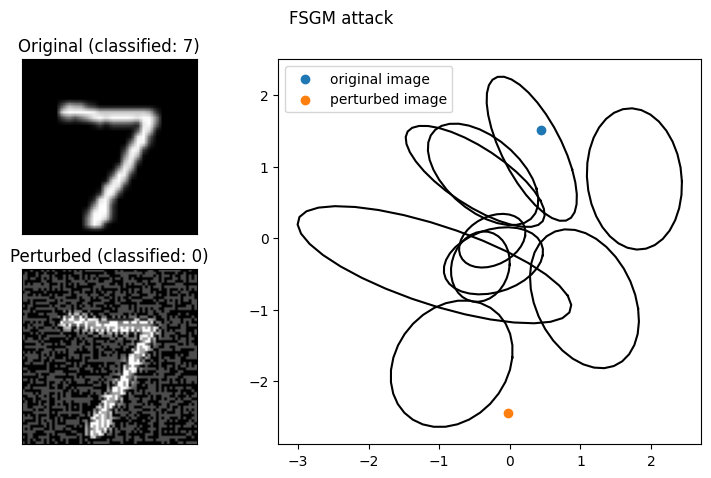

In [71]:
show_fsgm_attack(seven, 7, epsilon=0.3)

### FSGM (latent)

In [83]:
def latent_fsgm_attack(image: torch.Tensor, target: int, epsilon: float):
    og_device = image.device
    img_cuda = image.cuda().requires_grad_()
    latent_img = vae.encode(img_cuda)
    logits = gmm.log_posterior(latent_img)
    init_pred = logits.argmax().item()
    loss = F.nll_loss(logits, torch.as_tensor(target, device='cuda'))
    data_grad: torch.Tensor = torch.autograd.grad(loss, latent_img)[0]
    sign_data_grad = data_grad.sign()
    perturbed_latent_img = latent_img + epsilon*sign_data_grad
    perturbed_pred = gmm.log_posterior(perturbed_latent_img).argmax().item()
    perturbed_img = vae.decode(perturbed_latent_img)
    return perturbed_img.to(og_device), perturbed_latent_img.to(og_device), init_pred, perturbed_pred

In [86]:
from matplotlib.gridspec import GridSpec
def show_latent_fsgm_attack(image: torch.Tensor, target: int, epsilon: float):
    fig = plt.figure(figsize=(9, 5))
    gs = GridSpec(1, 2, width_ratios=[1, 2], figure=fig)
    axr = fig.add_subplot(gs[0, 1])
    gs_left = gs[0, 0].subgridspec(2, 1)
    axlu = fig.add_subplot(gs_left[0, 0])
    axll = fig.add_subplot(gs_left[1, 0])
    show_img(image, ax=axlu)
    perturbed, perturbed_latent, init_pred, final_pred = latent_fsgm_attack(image, target, epsilon)
    show_img(perturbed, ax=axll)
    axlu.set_title(f'Original (classified: {init_pred})')
    axll.set_title(f'Perturbed (classified: {final_pred})')
    plot_2d_gmm(gmm.means, gmm.covs, ax=axr)
    axr.scatter(*vae.encode(image).detach(), label='original image')
    axr.scatter(*perturbed_latent.detach(), label='perturbed image')
    axr.legend()

    fig.suptitle('FSGM attack')

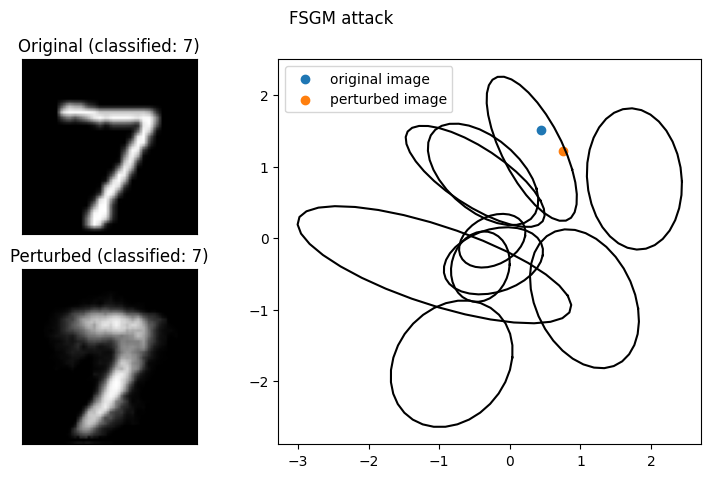

In [161]:
show_latent_fsgm_attack(seven, 7, epsilon=.3)

### Experimenting with gradient flows of posterior components

In [125]:
def class_grad_flat(coords: torch.Tensor, cls: int):
    og_device = coords.device
    class_post_batched = lambda x: torch.exp(gmm.log_posterior(x)[...,cls]).sum()
    return torch.autograd.functional.jacobian(class_post_batched, coords.cuda()).to(og_device)
def class_grad_sharp(coords: torch.Tensor, cls: int):
    og_device = coords.device
    coords_cuda = coords.cuda()
    grad_flat = class_grad_flat(coords_cuda, cls)
    return torch.linalg.solve(M.g(coords_cuda).detach(), grad_flat).to(og_device)

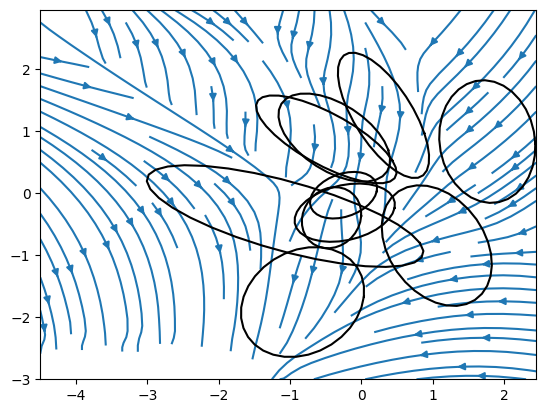

In [ ]:
grid_grad_flat = class_grad_flat(grid, cls=0).numpy()
X_m, Y_m = np.moveaxis(grid.numpy(), -1, 0)
plt.streamplot(X_m, Y_m, grid_grad_flat[...,0], grid_grad_flat[...,1])
plot_2d_gmm(gmm.means, gmm.covs)
plt.show()

/tmp/user/5678/ipykernel_3297494/1279070360.py:3: RuntimeWarning: invalid value encountered in sqrt
  speed = np.sqrt(np.einsum('...i,...i->...', grid_grad_flat, grid_grad_sharp))


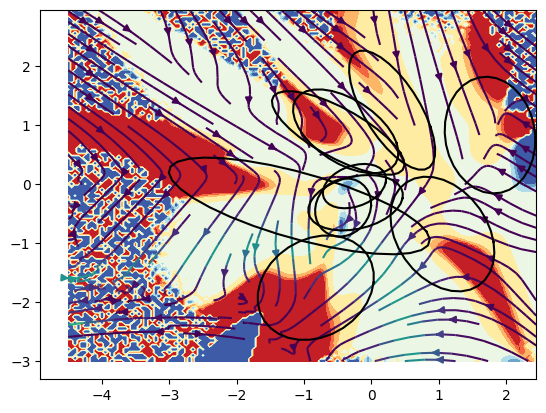

In [137]:
grid_grad_flat = class_grad_flat(grid, cls=0).numpy()
grid_grad_sharp = class_grad_sharp(grid, cls=0).numpy()
speed = np.sqrt(np.einsum('...i,...i->...', grid_grad_flat, grid_grad_sharp))
X_m, Y_m = np.moveaxis(grid.numpy(), -1, 0)
ric_grid = torch.clamp(M.ric(grid.cuda()).detach().cpu(), min=-30, max=30)
plt.contourf(X, Y, ric_grid, cmap='RdYlBu')
plt.streamplot(X_m, Y_m, grid_grad_sharp[...,0], grid_grad_sharp[...,1], color=speed)
plot_2d_gmm(gmm.means, gmm.covs)
plt.show()

In [148]:
def categorical_entropy_lp(log_probs: torch.Tensor, dim=-1):
    return -torch.sum(torch.exp(log_probs) * log_probs, dim=dim)

In [ ]:
def entropy_grad(coords: torch.Tensor):
    og_device = coords.device
    coords_cuda = coords.cuda()
    entropy_batched = lambda x: categorical_entropy_lp(gmm.log_posterior(x)).sum()
    flat =  torch.autograd.functional.jacobian(entropy_batched, coords_cuda)
    sharp = torch.linalg.solve(M.g(coords_cuda).detach(), flat)
    speed = torch.sqrt(torch.einsum('...i,...i->...', flat, sharp))
    return sharp.to(og_device), speed.to(og_device)

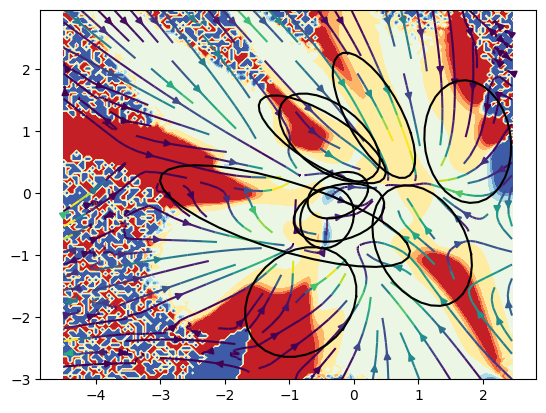

In [160]:
e_grad, speed = entropy_grad(grid)
e_grad, speed = e_grad.numpy(), torch.clamp(speed, 0, 1).numpy()
X_m, Y_m = np.moveaxis(grid.numpy(), -1, 0)
ric_grid = torch.clamp(M.ric(grid.cuda()).detach().cpu(), min=-30, max=30)
plt.contourf(X, Y, ric_grid, cmap='RdYlBu')
plt.streamplot(X_m, Y_m, e_grad[...,0], e_grad[...,1], color=speed)
plot_2d_gmm(gmm.means, gmm.covs)
plt.show()

In [198]:
def clamp_eigvalsh(H: torch.Tensor, to_min=0.1) -> torch.Tensor:
    eigvals, eigvecs = torch.linalg.eigh(H)
    clamped_eigvals = torch.clamp(eigvals, min=to_min)
    return torch.einsum('...ik,...k,...jk->...ij', eigvecs, clamped_eigvals, eigvecs)

In [216]:
def random_step(coords: torch.Tensor, eps=0.2):
    og_device = coords.device
    coords_cuda = coords.cuda()
    flat_step = eps*torch.randn_like(coords_cuda)
    g_grid = M.g(coords_cuda).detach()
    g_grid_clamped = clamp_eigvalsh(g_grid)
    sharp_step = torch.linalg.solve(g_grid_clamped, flat_step)
    return (coords_cuda + sharp_step).to(og_device)

def random_walk(coords: torch.Tensor, n_steps: int, eps=0.2):
    og_device = coords.device
    coords_cuda = coords.cuda()
    for _ in trange(n_steps, desc='Computing random walk'):
        coords_cuda = random_step(coords_cuda, eps=eps) 
    return coords_cuda.to(og_device)

In [235]:
init_points = gmm.gmm.sample((1000,))

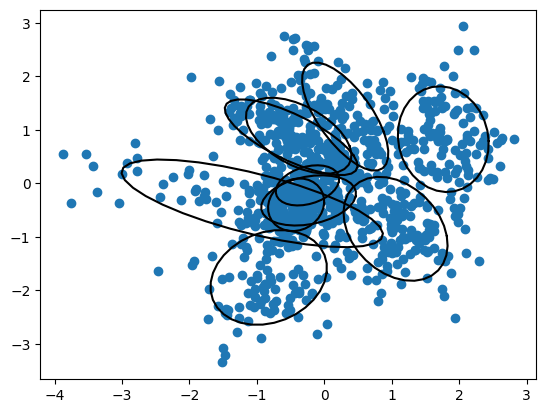

In [247]:
plot_2d_gmm(gmm.means, gmm.covs)
plt.scatter(*init_points.cpu().T) #type:ignore

In [254]:
grid_randwalk = random_walk(init_points, n_steps=300, eps=0.05)

Computing random walk: 100%|██████████| 300/300 [00:04<00:00, 61.16it/s]


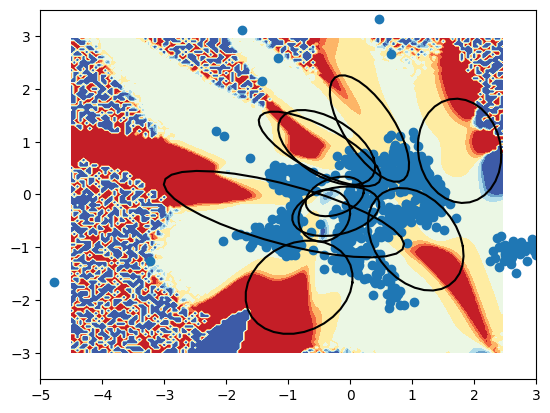

In [255]:
plt.contourf(X, Y, ric_grid, cmap='RdYlBu')
plot_2d_gmm(gmm.means, gmm.covs)
plt.scatter(*grid_randwalk.cpu().reshape(-1, 2).T) #type:ignore
plt.xlim(xmin, xmax)
plt.ylim(ymin, ymax)
plt.show()

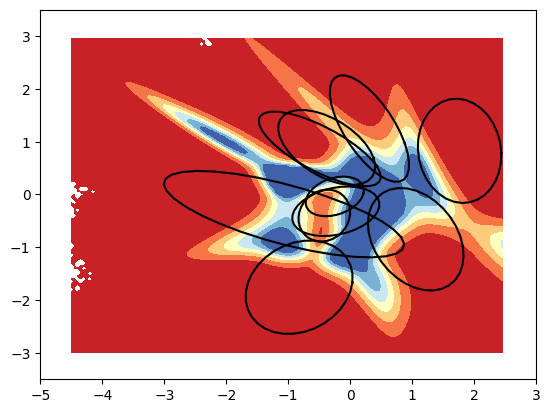

In [270]:
vol_grid = torch.clamp(torch.sqrt(torch.det(M.g(grid.cuda()).detach())).cpu(),max=5)
plt.contourf(X, Y, vol_grid, cmap='RdYlBu')
plot_2d_gmm(gmm.means, gmm.covs)
plt.xlim(xmin, xmax)
plt.ylim(ymin, ymax)
plt.show()

In [ ]:
def ric_grad(coords: torch.Tensor):
    og_device = coords.device
    coords_cuda = coords.cuda()
    ric_batched = lambda x: M.ric(x).sum()
    flat =  torch.autograd.functional.jacobian(ric_batched, coords_cuda)
    sharp = torch.linalg.solve(M.g(coords_cuda).detach(), flat)
    speed = torch.sqrt(torch.einsum('...i,...i->...', flat, sharp))
    return sharp.to(og_device), speed.to(og_device)

/net/st1/export/clusterhome/robertwiebe/testvenv/lib/python3.11/site-packages/numpy/ma/core.py:1071: RuntimeWarning: overflow encountered in multiply
  result = self.f(da, db, *args, **kwargs)
/net/st1/export/clusterhome/robertwiebe/testvenv/lib/python3.11/site-packages/matplotlib/colors.py:2243: UserWarning: Warning: converting a masked element to nan.
  dtype = np.min_scalar_type(value)
/net/st1/export/clusterhome/robertwiebe/testvenv/lib/python3.11/site-packages/matplotlib/colors.py:2250: UserWarning: Warning: converting a masked element to nan.
  data = np.asarray(value)


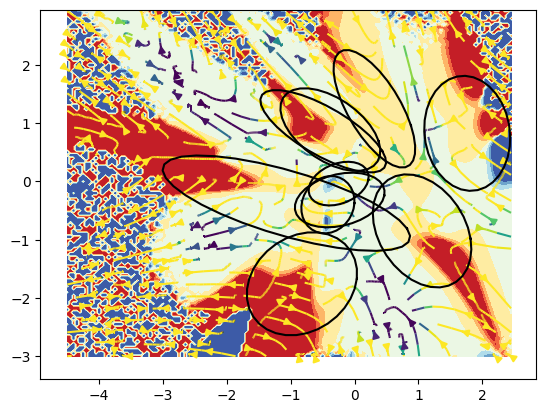

In [277]:
grad, speed = ric_grad(grid)
grad, speed = grad.numpy(), torch.clamp(speed, 0, 1).numpy()
X_m, Y_m = np.moveaxis(grid.numpy(), -1, 0)
ric_grid = torch.clamp(M.ric(grid.cuda()).detach().cpu(), min=-30, max=30)
plt.contourf(X, Y, ric_grid, cmap='RdYlBu')
plt.streamplot(X_m, Y_m, grad[...,0], grad[...,1], color=speed)
plot_2d_gmm(gmm.means, gmm.covs)
plt.show()